In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv( '/content/drive/MyDrive/Colab Notebooks/Diabetes_dataset_2026_ver3.csv', sep=';')
df.head()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
0,69,5,2839,1301,770,54,1304,440,500,905.0,1079,84,0,0,0,1,0
1,32,1,2649,1165,720,45,874,542,1299,1133.0,814,139,0,0,0,0,0
2,89,13,2534,1010,820,49,1125,568,1776,847.0,1072,79,0,0,0,1,0
3,78,13,2991,1460,1040,57,507,391,1170,1089.0,1100,99,0,0,0,1,1
4,38,8,2456,1032,740,47,1025,291,1459,841.0,928,91,0,1,0,0,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9538 entries, 0 to 9537
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9538 non-null   int64  
 1   Pregnancies         9538 non-null   int64  
 2   BMI                 9538 non-null   int64  
 3   Glucose             9538 non-null   int64  
 4   BloodPressure       9538 non-null   int64  
 5   HbA1c               9538 non-null   int64  
 6   LDL                 9538 non-null   int64  
 7   HDL                 9538 non-null   int64  
 8   Triglycerides       9538 non-null   int64  
 9   WaistCircumference  9535 non-null   float64
 10  HipCircumference    9538 non-null   int64  
 11  WHR                 9538 non-null   int64  
 12  FamilyHistory       9538 non-null   int64  
 13  DietType            9538 non-null   int64  
 14  Hypertension        9538 non-null   int64  
 15  MedicationUse       9538 non-null   int64  
 16  Outcom

In [ ]:
print(df['BMI'].value_counts())

BMI
150     225
228      13
278      13
2549     13
2741     12
       ... 
4966      1
211       1
4731      1
364       1
3839      1
Name: count, Length: 2378, dtype: int64


In [ ]:
df.describe()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
count,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9535.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000
mean,53.577584,7.986161,2436.773537,1061.041833,844.757811,46.506605,1001.334557,499.534179,1511.477459,939.531620,1030.606207,83.366534,0.302474,0.486161,0.001048,0.405012,0.344097
std,20.764651,4.933469,968.048837,219.185896,141.234796,4.763948,299.119097,152.421935,489.516273,155.965971,134.388269,28.328990,0.459354,0.661139,0.032364,0.490920,0.475098
min,18.000000,0.000000,150.000000,500.000000,600.000000,40.000000,-120.000000,-92.000000,500.000000,403.000000,548.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,4.000000,2111.000000,910.000000,740.000000,43.000000,801.000000,397.000000,1172.000000,834.000000,940.000000,78.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,8.000000,2625.000000,1060.000000,840.000000,46.000000,999.000000,502.000000,1505.500000,938.000000,1032.000000,89.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,12.000000,3065.750000,1210.000000,940.000000,50.000000,1202.000000,602.000000,1851.000000,1046.000000,1121.000000,99.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,16.000000,4966.000000,2072.000000,1380.000000,69.000000,2022.000000,1078.000000,3458.000000,1630.000000,1566.000000,149.000000,1.000000,2.000000,1.000000,1.000000,1.000000


In [ ]:
print("jumlah data kosong =")
print(df.isnull().sum())
print(f'\njumlah data duplikat = {df.duplicated().sum()}')

jumlah data kosong =
Age                   0
Pregnancies           0
BMI                   0
Glucose               0
BloodPressure         0
HbA1c                 0
LDL                   0
HDL                   0
Triglycerides         0
WaistCircumference    3
HipCircumference      0
WHR                   0
FamilyHistory         0
DietType              0
Hypertension          0
MedicationUse         0
Outcome               0
dtype: int64

jumlah data duplikat = 0



 Matriks Korelasi 
                         Age  Pregnancies       BMI   Glucose  BloodPressure  \
Age                 1.000000     0.010714  0.034693  0.487808       0.429335   
Pregnancies         0.010714     1.000000 -0.010217  0.007126      -0.008272   
BMI                 0.034693    -0.010217  1.000000  0.355295       0.377842   
Glucose             0.487808     0.007126  0.355295  1.000000       0.541987   
BloodPressure       0.429335    -0.008272  0.377842  0.541987       1.000000   
HbA1c               0.396354     0.009060  0.303047  0.817493       0.444980   
LDL                -0.003871     0.006717  0.026401  0.019576       0.000265   
HDL                -0.009566    -0.000258 -0.017570 -0.020587      -0.011031   
Triglycerides       0.010470     0.005732 -0.003767 -0.008765      -0.014742   
WaistCircumference  0.025609    -0.018678  0.461998  0.428975       0.460169   
HipCircumference    0.020944    -0.006866  0.410820  0.372786       0.400626   
WHR                 

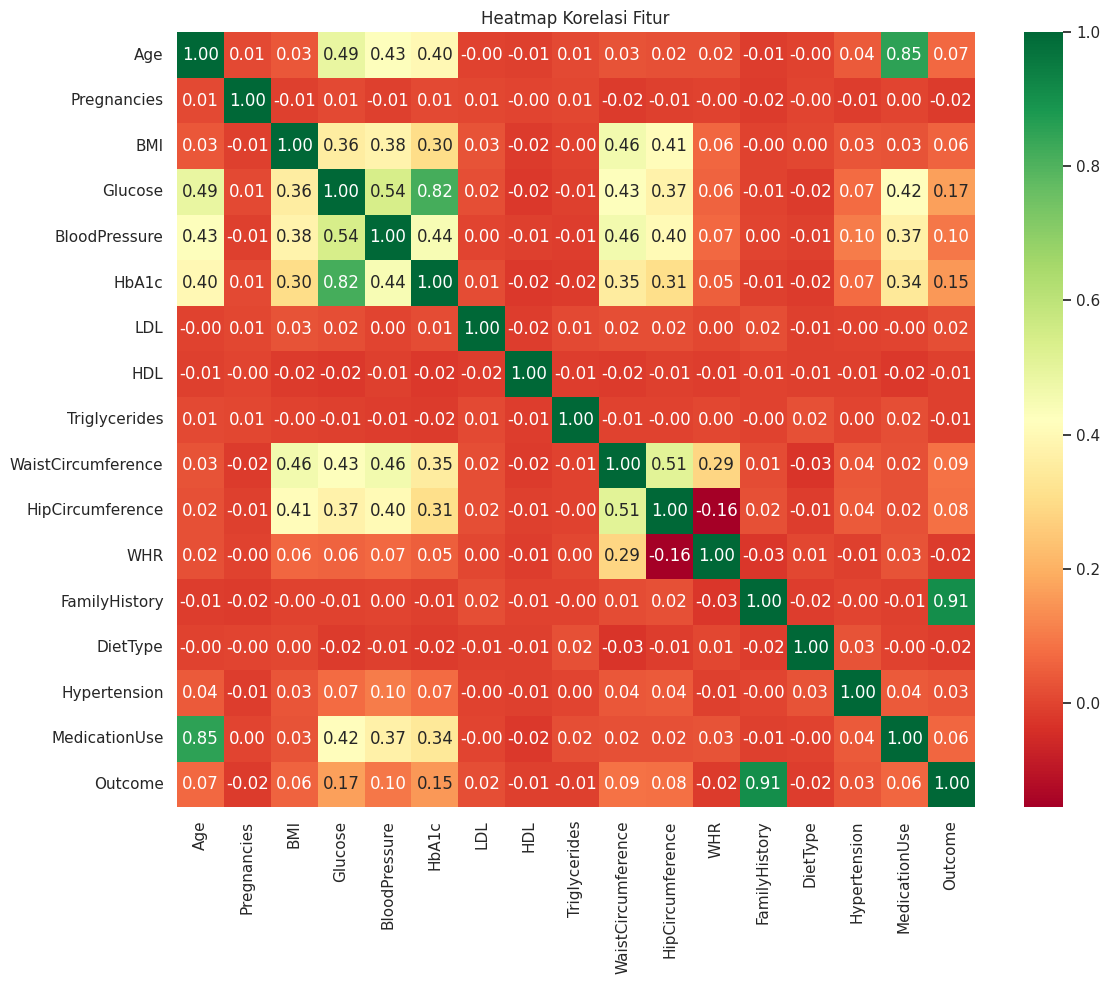

In [ ]:
print("\n Matriks Korelasi ")
correlation_matrix = df.corr()
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='RdYlGn')
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

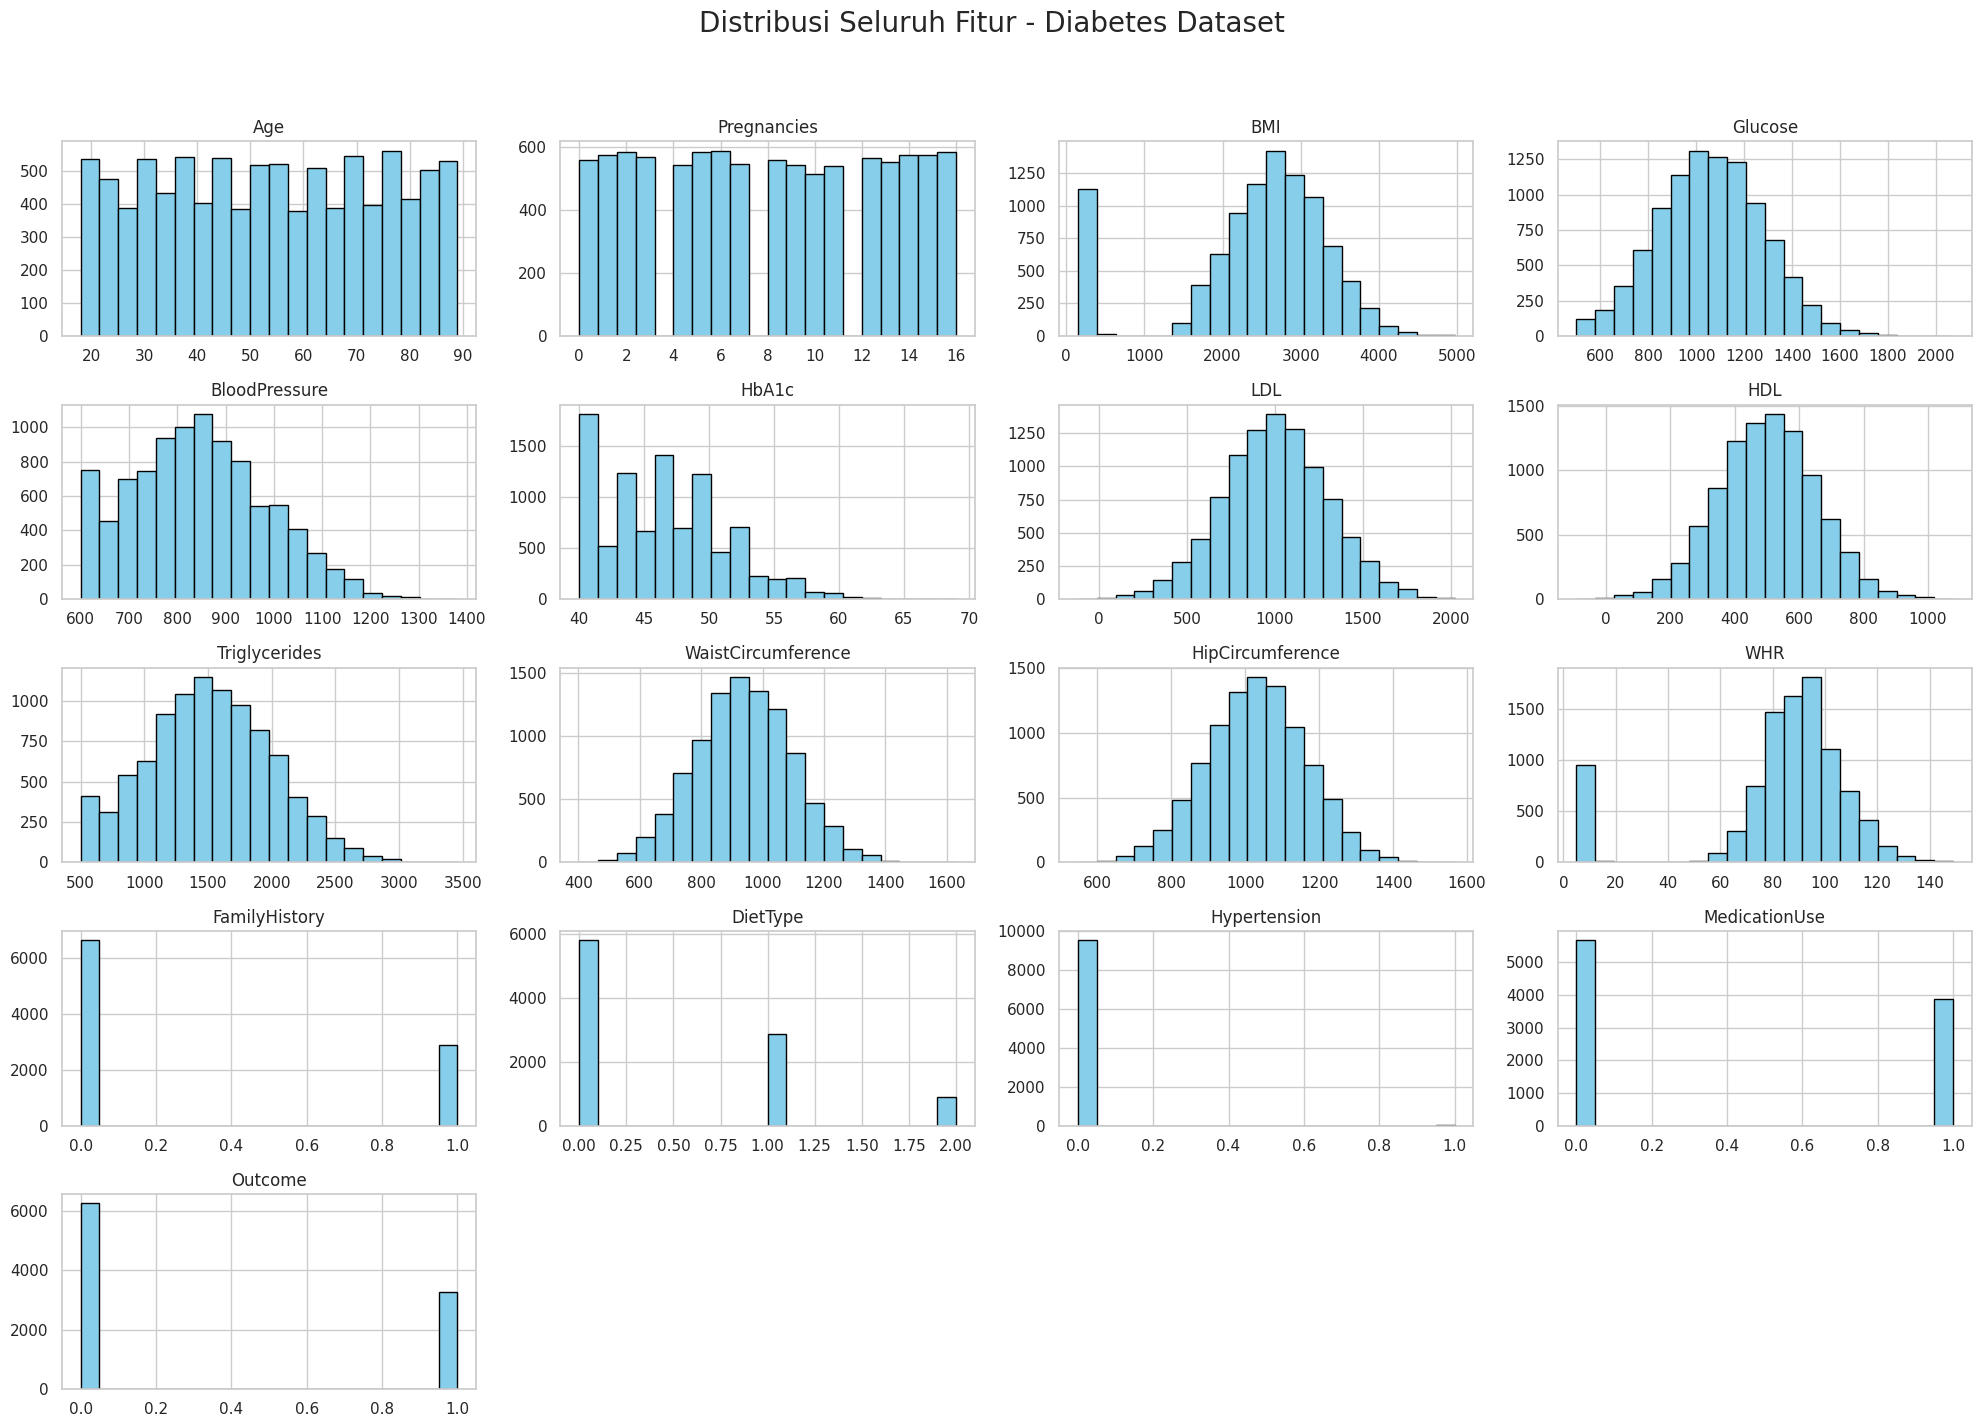

In [ ]:
sns.set_theme(style="whitegrid")
df.hist(bins=20, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Seluruh Fitur - Diabetes Dataset', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)
print(df.describe())

               Age  Pregnancies          BMI      Glucose  BloodPressure  \
count  9538.000000  9538.000000  9538.000000  9538.000000    9538.000000   
mean     53.577584     7.986161  2436.773537  1061.041833     844.757811   
std      20.764651     4.933469   968.048837   219.185896     141.234796   
min      18.000000     0.000000   150.000000   500.000000     600.000000   
25%      36.000000     4.000000  2111.000000   910.000000     740.000000   
50%      53.000000     8.000000  2625.000000  1060.000000     840.000000   
75%      72.000000    12.000000  3065.750000  1210.000000     940.000000   
max      89.000000    16.000000  4966.000000  2072.000000    1380.000000   

             HbA1c          LDL          HDL  Triglycerides  \
count  9538.000000  9538.000000  9538.000000    9538.000000   
mean     46.506605  1001.334557   499.534179    1511.477459   
std       4.763948   299.119097   152.421935     489.516273   
min      40.000000  -120.000000   -92.000000     500.000000   


In [ ]:
def fix_health_data(row):
    # Koreksi bagi 10 (hasil 1 desimal)
    if row['HbA1c'] > 20:
        row['HbA1c'] = round(row['HbA1c'] / 10, 1)
    if row['Glucose'] > 300:
        row['Glucose'] = round(row['Glucose'] / 10, 1)
    if row['BloodPressure'] > 200:
        row['BloodPressure'] = round(row['BloodPressure'] / 10, 1)

    # Profil Lipid (LDL/HDL/Triglycerides)
    for col in ['LDL', 'HDL', 'Triglycerides']:
        if row[col] > 600:
            row[col] = round(row[col] / 10, 1)

    # Lingkar Pinggang/Pinggul (Waist/Hip)
    for col in ['WaistCircumference', 'HipCircumference']:
        if row[col] > 300:
            row[col] = round(row[col] / 10, 1)

    # Koreksi bagi 100 (hasil 2 desimal)
    if row['BMI'] > 100:
        row['BMI'] = round(row['BMI'] / 100, 2)
    if row['WHR'] > 2:
        row['WHR'] = round(row['WHR'] / 100, 2)

    return row

df_fixed = df.apply(fix_health_data, axis=1)
print(df_fixed.describe())

               Age  Pregnancies          BMI      Glucose  BloodPressure  \
count  9538.000000  9538.000000  9538.000000  9538.000000    9538.000000   
mean     53.577584     7.986161    24.367735   106.104183      84.475781   
std      20.764651     4.933469     9.680488    21.918590      14.123480   
min      18.000000     0.000000     1.500000    50.000000      60.000000   
25%      36.000000     4.000000    21.110000    91.000000      74.000000   
50%      53.000000     8.000000    26.250000   106.000000      84.000000   
75%      72.000000    12.000000    30.657500   121.000000      94.000000   
max      89.000000    16.000000    49.660000   207.200000     138.000000   

             HbA1c          LDL          HDL  Triglycerides  \
count  9538.000000  9538.000000  9538.000000    9538.000000   
mean      4.650661   135.911051   342.573537     167.639316   
std       0.476395   108.157515   186.071698      81.316064   
min       4.000000  -120.000000   -92.000000      60.100000   


In [ ]:
vital_cols = ['BMI', 'Glucose', 'BloodPressure', 'HbA1c']
df_fixed[vital_cols] = df_fixed[vital_cols].replace(0, np.nan)
for col in vital_cols:
    median_val = df_fixed[col].median()
    df_fixed[col] = df_fixed[col].fillna(median_val)
print("5 Baris Pertama Setelah Imputasi Nol:")
print(df_fixed.head())

health_cols = ['BMI', 'Glucose', 'BloodPressure', 'HbA1c', 'LDL', 'HDL', 'Triglycerides', 'WHR']
summary_stats = df_fixed[health_cols].describe().loc[['mean', 'min', 'max']]
print("\nRingkasan Statistik Deskriptif (Kesehatan Utama):")
print(summary_stats)

5 Baris Pertama Setelah Imputasi Nol:
    Age  Pregnancies    BMI  Glucose  BloodPressure  HbA1c    LDL    HDL  \
0  69.0          5.0  28.39    130.1           77.0    5.4  130.4  440.0   
1  32.0          1.0  26.49    116.5           72.0    4.5   87.4  542.0   
2  89.0         13.0  25.34    101.0           82.0    4.9  112.5  568.0   
3  78.0         13.0  29.91    146.0          104.0    5.7  507.0  391.0   
4  38.0          8.0  24.56    103.2           74.0    4.7  102.5  291.0   

   Triglycerides  WaistCircumference  HipCircumference   WHR  FamilyHistory  \
0          500.0                90.5             107.9  0.84            0.0   
1          129.9               113.3              81.4  1.39            0.0   
2          177.6                84.7             107.2  0.79            0.0   
3          117.0               108.9             110.0  0.99            0.0   
4          145.9                84.1              92.8  0.91            0.0   

   DietType  Hypertension  Med

In [ ]:
exclude_cols = ['FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse', 'Outcome']
numeric_cols = [col for col in df_fixed.columns if col not in exclude_cols]

def get_outlier_counts(data, cols):
    counts = {}
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        counts[col] = ((data[col] < lower) | (data[col] > upper)).sum()
    return counts
outliers_before = get_outlier_counts(df_fixed, numeric_cols)
for col in numeric_cols:
    Q1 = df_fixed[col].quantile(0.25)
    Q3 = df_fixed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_fixed[col] = np.where(df_fixed[col] < lower_bound, lower_bound,
                             np.where(df_fixed[col] > upper_bound, upper_bound, df_fixed[col]))

outliers_after = get_outlier_counts(df_fixed, numeric_cols)
verification = pd.DataFrame({
    'Outliers Sebelum': outliers_before,
    'Outliers Sesudah': outliers_after
})
print(verification)

                    Outliers Sebelum  Outliers Sesudah
Age                                0                 0
Pregnancies                        0                 0
BMI                             1153                 0
Glucose                           34                 0
BloodPressure                     30                 0
HbA1c                             31                 0
LDL                              814                 0
HDL                                0                 0
Triglycerides                    357                 0
WaistCircumference                46                 0
HipCircumference                  55                 0
WHR                             1034                 0


In [ ]:
bmi_frequency = df_fixed['BMI'].value_counts().sort_index()
print("Nilai BMI dengan frekuensi tertinggi:")
print(df_fixed['BMI'].value_counts().head(10))
print(f"\nNilai BMI Minimum (Batas Bawah): {df_fixed['BMI'].min()}")
print(f"Nilai BMI Maksimum (Batas Atas): {df_fixed['BMI'].max()}")
lower_bound_count = (df_fixed['BMI'] == df_fixed['BMI'].min()).sum()
print(f"\nJumlah data pada batas bawah (capping): {lower_bound_count}")

Nilai BMI dengan frekuensi tertinggi:
BMI
6.78875     1142
25.49000      13
27.41000      12
31.73000      12
25.95000      12
25.93000      12
26.88000      12
28.29000      12
28.39000      12
27.52000      11
Name: count, dtype: int64

Nilai BMI Minimum (Batas Bawah): 6.78875
Nilai BMI Maksimum (Batas Atas): 44.97875

Jumlah data pada batas bawah (capping): 1142


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Glucose'])
y = df['Glucose']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 11693.010899724748
R-squared: 0.7465448323168578


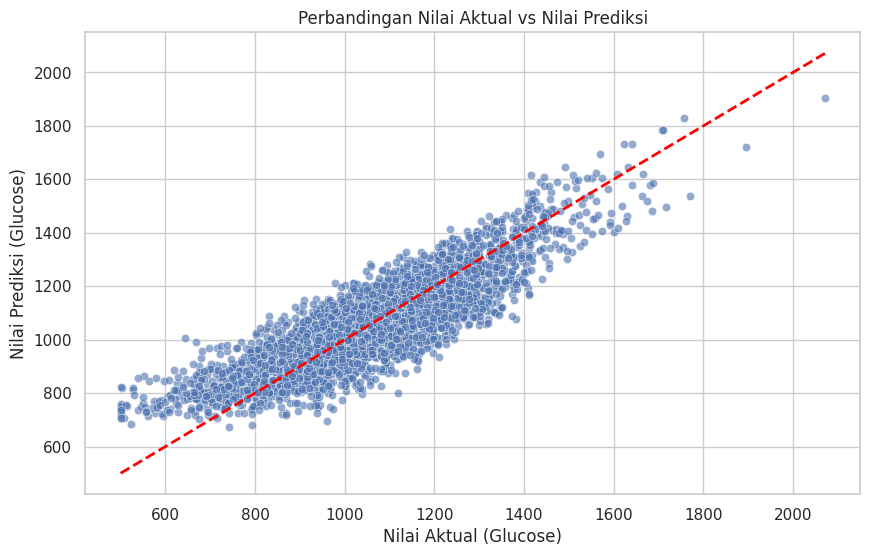

In [ ]:
# Membuat scatter plot nilai aktual vs prediksi
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Menambahkan garis diagonal y=x sebagai referensi
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.xlabel('Nilai Aktual (Glucose)')
plt.ylabel('Nilai Prediksi (Glucose)')
plt.title('Perbandingan Nilai Aktual vs Nilai Prediksi')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
exclude_cols = ['FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse', 'Outcome']
numeric_cols = [col for col in df.columns if col not in exclude_cols]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df.head())

        Age  Pregnancies       BMI   Glucose  BloodPressure     HbA1c  \
0  0.742763    -0.605318  0.415524  1.094828      -0.529344  1.573021   
1 -1.039204    -1.416149  0.219243  0.474317      -0.883383 -0.316268   
2  1.705989     1.016344  0.100441 -0.232882      -0.175305  0.523416   
3  1.176215     1.016344  0.572549  1.820277       1.382467  2.202783   
4 -0.750237     0.002805  0.019862 -0.132506      -0.741767  0.103574   

        LDL       HDL  Triglycerides  WaistCircumference  HipCircumference  \
0  1.011909 -0.390608      -2.066388           -0.221448          0.360123   
1 -0.425721  0.278622      -0.434079            1.240716         -1.611879   
2  0.413454  0.449210       0.540404           -0.593402          0.308033   
3 -1.652721 -0.712101      -0.697618            0.958544          0.516395   
4  0.079121 -1.368209      -0.107208           -0.631880         -0.763546   

        WHR  FamilyHistory  DietType  Hypertension  MedicationUse  Outcome  
0  0.022362    

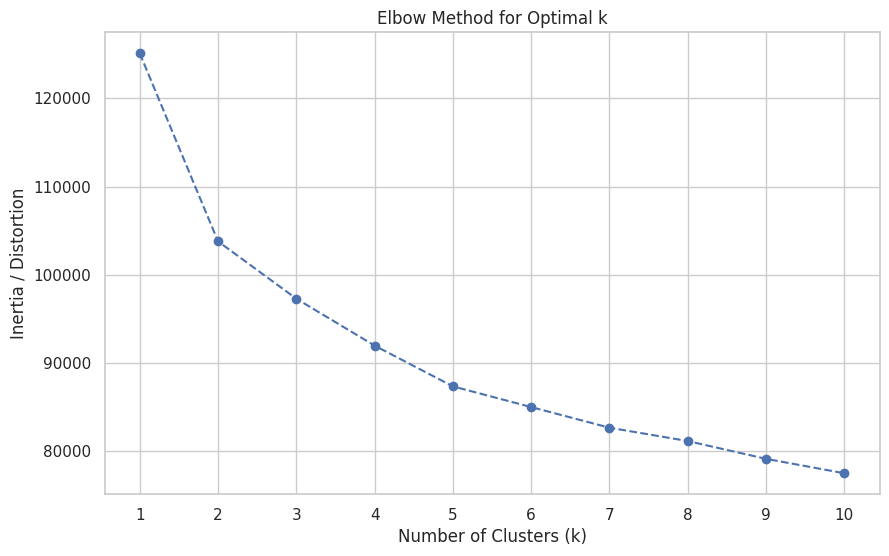

Berdasarkan grafik Elbow Method di atas, titik di mana penurunan inertia mulai melambat (membentuk siku) menunjukkan nilai k optimal.
Nilai k optimal yang diperoleh adalah: 3


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate distortion/inertia for a range of k values
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method visualization
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / Distortion')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

print("Berdasarkan grafik Elbow Method di atas, titik di mana penurunan inertia mulai melambat (membentuk siku) menunjukkan nilai k optimal.")
print("Nilai k optimal yang diperoleh adalah: 3")

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11) # Silhouette score requires at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score untuk k={k}: {score:.4f}")

# Menentukan k terbaik
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\nJumlah cluster (k) terbaik berdasarkan Silhouette Score adalah k={best_k} dengan skor {best_score:.4f}")

Silhouette Score untuk k=2: 0.1505
Silhouette Score untuk k=3: 0.0984
Silhouette Score untuk k=4: 0.0956
Silhouette Score untuk k=5: 0.1007
Silhouette Score untuk k=6: 0.0893
Silhouette Score untuk k=7: 0.0857
Silhouette Score untuk k=8: 0.0745
Silhouette Score untuk k=9: 0.0839
Silhouette Score untuk k=10: 0.0795

Jumlah cluster (k) terbaik berdasarkan Silhouette Score adalah k=2 dengan skor 0.1505


In [ ]:
# Melakukan clustering dengan k optimal (k=2)
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df)

print("Clustering selesai. Label cluster telah ditambahkan ke DataFrame.")
display(df[['Cluster']].head())

Clustering selesai. Label cluster telah ditambahkan ke DataFrame.


,Cluster
0,1
1,0
2,1
3,1
4,0


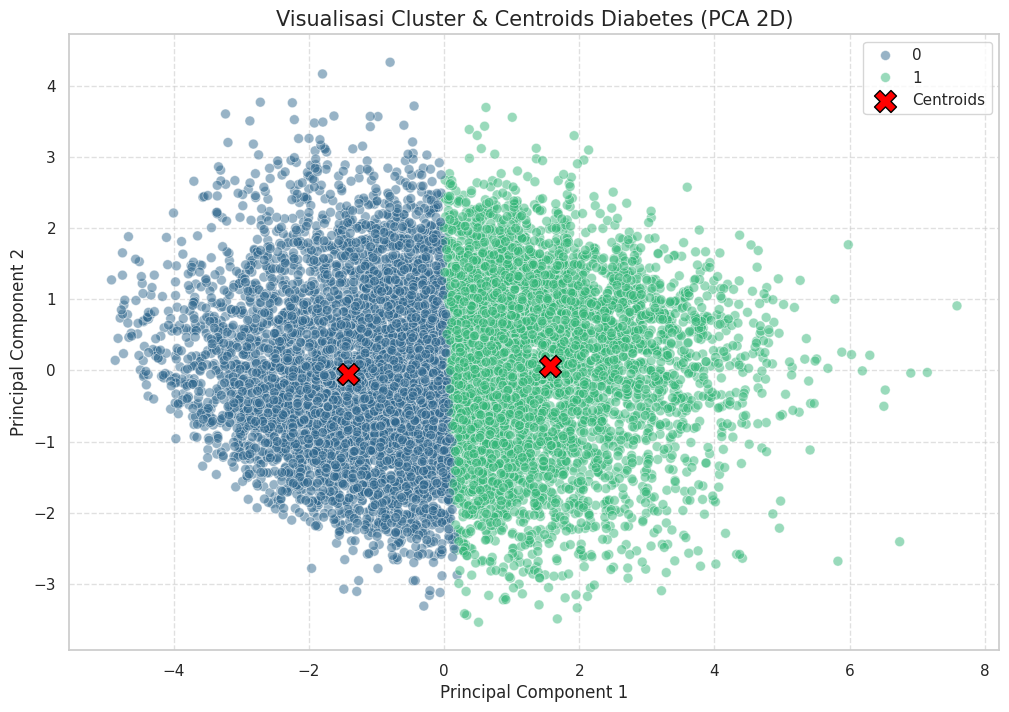

Rasio varians yang dijelaskan: 37.21%


In [ ]:
from sklearn.decomposition import PCA

# 1. Menyiapkan fitur (tanpa kolom Cluster)
X_features = df.drop(columns=['Cluster'])

# 2. Inisialisasi PCA untuk 2 dimensi
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_features)

# 3. Mentransformasikan Centroids ke dalam ruang PCA yang sama
# Mengonversi centroids ke DataFrame agar memiliki nama fitur yang sama dengan data fitting
centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=X_features.columns)
centroids_pca = pca.transform(centroids)

# 4. Membuat DataFrame untuk plotting
df_pca_viz = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca_viz['Cluster'] = df['Cluster'].values

# 5. Visualisasi
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_viz, palette='viridis', alpha=0.5, s=50)

# Plot Centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=250, marker='X', label='Centroids', edgecolor='black')

plt.title('Visualisasi Cluster & Centroids Diabetes (PCA 2D)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Rasio varians yang dijelaskan: {pca.explained_variance_ratio_.sum():.2%}")

### Persiapan Data untuk Klasifikasi
Langkah-langkah berikut mencakup pembagian data dan standarisasi fitur.

In [ ]:
# 1. Impor fungsi yang diperlukan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df_fixed.drop(columns=['Outcome'])
y = df_fixed['Outcome']

x_nb_train, x_nb_test, y_nb_train, y_nb_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_nb = StandardScaler()
x_nb_train = scaler_nb.fit_transform(x_nb_train)
x_nb_test = scaler_nb.transform(x_nb_test)

x_nb_full_scaled = scaler_nb.fit_transform(X)

print("Pembagian data dan standarisasi selesai.")

Pembagian data dan standarisasi selesai.


In [ ]:
from sklearn.naive_bayes import GaussianNB
naive_bayes = GaussianNB()
naive_bayes.fit(x_nb_train, y_nb_train)
y_pred_nb = naive_bayes.predict(x_nb_test_)


### 6. Evaluasi Model Naive Bayes

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Evaluate the model using Naive Bayes test target and predictions
accuracy_nb = accuracy_score(y_nb_test, y_pred_nb)
precision_nb = precision_score(y_nb_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_nb_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_nb_test, y_pred_nb, average='weighted', zero_division=0)
conf_matrix_nb = confusion_matrix(y_nb_test, y_pred_nb)
class_report_nb = classification_report(y_nb_test, y_pred_nb, zero_division=0)

print(f"Naive Bayes Model Evaluation:\n")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix_nb}")
print(f"\nClassification Report:\n{class_report_nb}")

Naive Bayes Model Evaluation:

Accuracy: 0.9616
Precision: 0.9637
Recall: 0.9616
F1-Score: 0.9610

Confusion Matrix:
[[1892    0]
 [ 110  860]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      1892
         1.0       1.00      0.89      0.94       970

    accuracy                           0.96      2862
   macro avg       0.97      0.94      0.96      2862
weighted avg       0.96      0.96      0.96      2862



In [64]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix




# Display class distribution before sampling
print("Class distribution in training data before sampling:")
print(pd.Series(y_nb_train).value_counts())

smote = SMOTE(random_state=42)
x_nb_train_resampled, y_nb_train_resampled = smote.fit_resample(x_nb_train, y_nb_train)
print(f"\nClass distribution in training data after SMOTE sampling:")
print(pd.Series(y_nb_train_resampled).value_counts())

Class distribution in training data before sampling:
Outcome
0.0    4364
1.0    2312
Name: count, dtype: int64

Class distribution in training data after SMOTE sampling:
Outcome
1.0    4364
0.0    4364
Name: count, dtype: int64


In [66]:
naive_bayes_model_smote = GaussianNB()
naive_bayes_model_smote.fit(x_nb_train_resampled, y_nb_train_resampled)
y_pred_nb_smote = naive_bayes_model_smote.predict(x_nb_test)


--- Naive Bayes Model Evaluation (SMOTE) ---

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      1892
         1.0       1.00      0.89      0.94       970

    accuracy                           0.96      2862
   macro avg       0.97      0.94      0.96      2862
weighted avg       0.96      0.96      0.96      2862





Text(404.4318181818181, 0.5, 'Actual')

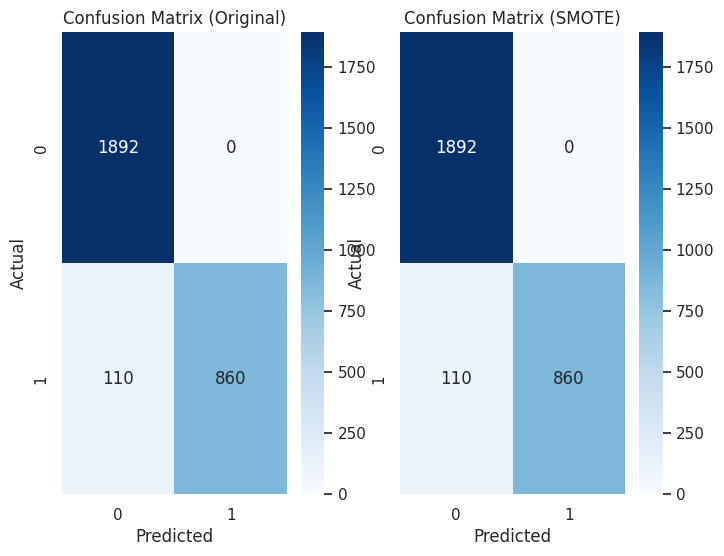

In [69]:
print(f"\n--- Naive Bayes Model Evaluation (SMOTE) ---\n")
print(classification_report(y_nb_test, y_pred_nb_smote))

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
cm_original = confusion_matrix(y_nb_test, y_pred_nb)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix (Original)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')
print("\n")

cm_resampled = confusion_matrix(y_nb_test, y_pred_nb_smote)
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix (SMOTE)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')




### 8. Export Model dan Scaler ke File .pkl

In [71]:
import pickle
import os

# 1. Simpan model Linear Regression dan Scaler-nya
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open( 'linear_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Simpan model Naive Bayes (SMOTE) dan Scaler-nya
with open('naive_bayes_smote_model.pkl', 'wb') as f:
    pickle.dump(naive_bayes_model_smote, f)
with open('naive_bayes_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_nb, f)

print("Konfirmasi: Seluruh model dan scaler telah berhasil disimpan di folder:")

Konfirmasi: Seluruh model dan scaler telah berhasil disimpan di folder:


In [75]:
%%bash
pip install -q streamlit

In [76]:
!pip install streamlit
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Writing the Streamlit app to a file correctly using triple quotes
with open('app.py', 'w') as f:
    f.write('''
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Load models and scalers
with open('linear_regression_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)
with open('linear_scaler.pkl', 'rb') as f:
    lr_scaler = pickle.load(f)
with open('naive_bayes_smote_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)
with open('naive_bayes_scaler.pkl', 'rb') as f:
    nb_scaler = pickle.load(f)

# Sidebar Navigation
st.sidebar.title("Dashboard Diabetes")
page = st.sidebar.radio("Pilih Halaman:", ["Prediksi Glucose (Linear Regression)", "Klasifikasi Outcome (Naive Bayes)"])

if page == "Prediksi Glucose (Linear Regression)":
    st.title("📈 Prediksi Kadar Glucose")
    st.write("Masukkan data fitur untuk memprediksi nilai Glucose.")

    lr_features = ['Age', 'Pregnancies', 'BMI', 'BloodPressure', 'HbA1c', 'LDL', 'HDL', 'Triglycerides', 'WaistCircumference', 'HipCircumference', 'WHR', 'FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse', 'Outcome']

    input_data = []
    col1, col2 = st.columns(2)
    for i, feat in enumerate(lr_features):
        with col1 if i % 2 == 0 else col2:
            val = st.number_input(f"{feat}", value=0.0, key=f"lr_{feat}")
            input_data.append(val)

    if st.button("Hitung Prediksi Glucose"):
        input_arr = np.array([input_data])
        scaled_data = lr_scaler.transform(input_arr)
        prediction = lr_model.predict(scaled_data)
        st.success(f"Prediksi Nilai Glucose: {prediction[0]:.2f}")

elif page == "Klasifikasi Outcome (Naive Bayes)":
    st.title("🩺 Klasifikasi Risiko Diabetes")
    st.write("Masukkan data fitur untuk menentukan klasifikasi Outcome (Diabetes/Tidak).")

    nb_features = ['Age', 'Pregnancies', 'BMI', 'Glucose', 'BloodPressure', 'HbA1c', 'LDL', 'HDL', 'Triglycerides', 'WaistCircumference', 'HipCircumference', 'WHR', 'FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse']

    input_data = []
    col1, col2 = st.columns(2)
    for i, feat in enumerate(nb_features):
        with col1 if i % 2 == 0 else col2:
            val = st.number_input(f"{feat}", value=0.0, key=f"nb_{feat}")
            input_data.append(val)

    if st.button("Klasifikasi Data"):
        input_arr = np.array([input_data])
        scaled_data = nb_scaler.transform(input_arr)
        prediction = nb_model.predict(scaled_data)

        if prediction[0] == 1:
            st.error("Hasil: Diabetes (Positif)")
        else:
            st.success("Hasil: Tidak Diabetes (Negatif)")
''')

print("File app.py berhasil dibuat.")

File app.py berhasil dibuat.


In [78]:
!pip install pyngrok
from pyngrok import ngrok
import subprocess
import time

# Masukkan Auth Token Ngrok
ngrok.set_auth_token("3DFZMTfRieYmQpmrNh7dsOW9W25_6MvX5Mjdp7GWNZqZFaUnL")
ngrok.kill()

# Menjalankan Streamlit di background
process = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Tunggu beberapa detik agar server siap
time.sleep(5)

# Membuat tunnel publik
public_url = ngrok.connect(8501)
print(f"✅ Dashboard live di: {public_url}")

✅ Dashboard live di: NgrokTunnel: "https://juncture-john-cardigan.ngrok-free.dev" -> "http://localhost:8501"


### 4. Penjelasan Export Model dan Scaler

**Mengapa model perlu di-export menggunakan Pickle?**
Model perlu di-export agar hasil pelatihan yang memakan waktu dan sumber daya tidak hilang saat runtime berakhir. Dengan menyimpannya ke format `.pkl`, kita dapat memuat kembali model tersebut di lingkungan produksi atau aplikasi lain tanpa harus melatih ulang datanya dari awal.

**Apa kegunaan menyimpan scaler secara terpisah?**
Scaler harus disimpan karena data baru yang akan diprediksi di masa depan harus melalui **transformasi yang persis sama** (mean dan standar deviasi yang sama) dengan data yang digunakan saat pelatihan. Jika kita menggunakan scaler baru atau tidak melakukan standarisasi pada data input baru, model akan menerima data dengan distribusi yang berbeda, yang mengakibatkan prediksi menjadi tidak akurat atau salah.

### Confusion Matrix dan Classification Report

### 5. Mengapa proses standarisasi perlu dilakukan?

Proses standarisasi perlu dilakukan sebelum membangun model klasifikasi karena:

1.  **Skala yang Berbeda:** Fitur dalam dataset (seperti Age vs Glucose) memiliki rentang nilai yang sangat berbeda. Tanpa standarisasi, fitur dengan nilai besar akan mendominasi perhitungan model.
2.  **Algoritma Berbasis Jarak:** Banyak algoritma klasifikasi (seperti KNN atau SVM) sangat sensitif terhadap skala karena mereka menghitung jarak antar titik data.
3.  **Konvergensi Gradien:** Untuk algoritma yang menggunakan optimasi gradien (seperti Logistic Regression atau Neural Networks), standarisasi membantu model mencapai titik optimal (konvergensi) dengan lebih cepat dan stabil.